In [51]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
import os

DATASET_PATH = "448"

CRACK_PATH = os.path.join(DATASET_PATH, "Cracks")
NON_CRACK_PATH = os.path.join(DATASET_PATH, "NonCracks")

print("Dataset path:", DATASET_PATH)
print("Crack path:", CRACK_PATH)
print("Non-crack path:", NON_CRACK_PATH)

Dataset path: 448
Crack path: 448\Cracks
Non-crack path: 448\NonCracks


In [11]:
print("Dataset folder exists:", os.path.exists(DATASET_PATH))
print("Crack folder exists:", os.path.exists(CRACK_PATH))
print("Non-crack folder exists:", os.path.exists(NON_CRACK_PATH))

print("Number of crack images:", len(os.listdir(CRACK_PATH)))
print("Number of non-crack images:", len(os.listdir(NON_CRACK_PATH)))

Dataset folder exists: True
Crack folder exists: True
Non-crack folder exists: True
Number of crack images: 200
Number of non-crack images: 200


In [12]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

crack_images = [
    os.path.join(CRACK_PATH, file)
    for file in os.listdir(CRACK_PATH)
    if file.lower().endswith(valid_extensions)
]

non_crack_images = [
    os.path.join(NON_CRACK_PATH, file)
    for file in os.listdir(NON_CRACK_PATH)
    if file.lower().endswith(valid_extensions)
]

print("Crack images:", len(crack_images))
print("Non-crack images:", len(non_crack_images))
print("Total images:", len(crack_images) + len(non_crack_images))

Crack images: 200
Non-crack images: 200
Total images: 400


In [13]:
sample_path = crack_images[0]

image = cv2.imread(sample_path)

print("Image path:", sample_path)
print("Image shape:", image.shape)
print("Height:", image.shape[0])
print("Width:", image.shape[1])
print("Channels:", image.shape[2])
print("Data type:", image.dtype)

Image path: 448\Cracks\IMG_20180513_164959951_HDR resized_448.jpg
Image shape: (448, 448, 3)
Height: 448
Width: 448
Channels: 3
Data type: uint8


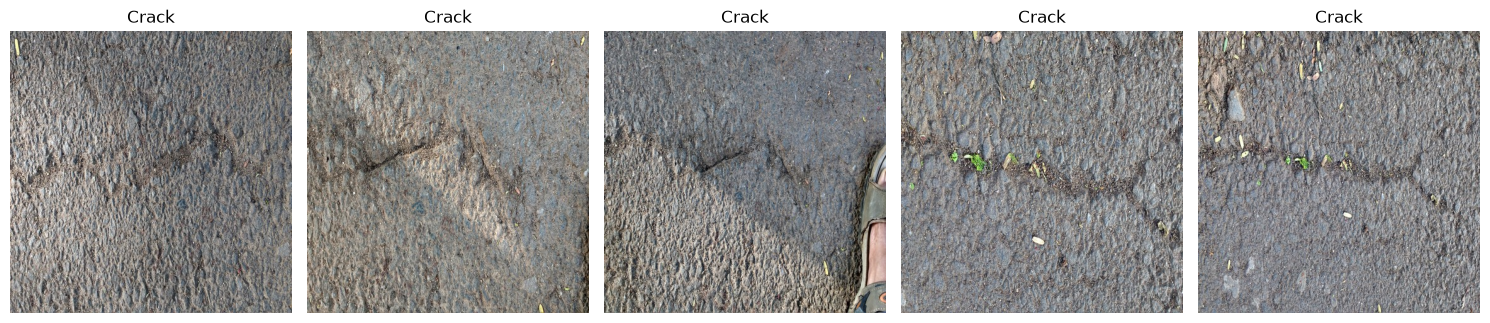

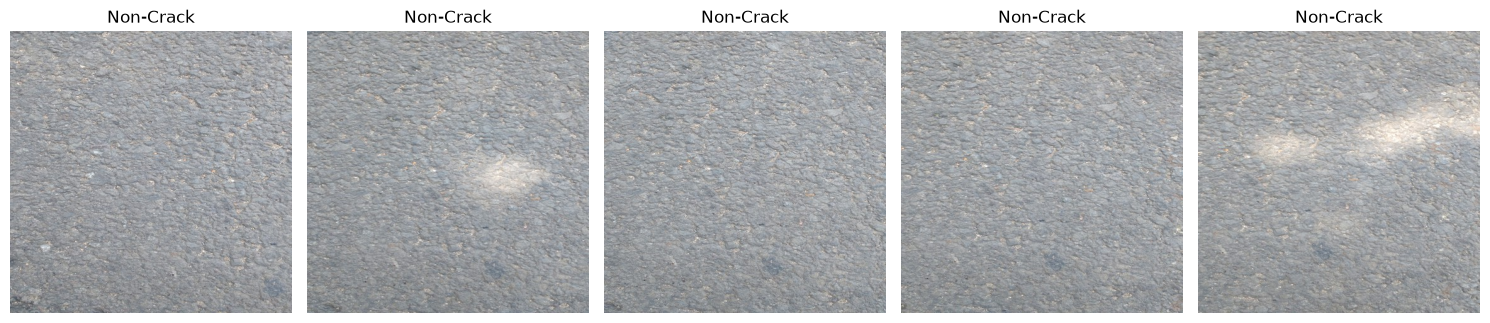

In [23]:
plt.figure(figsize=(15, 6))

for i in range(min(5, len(crack_images))):
    image = cv2.imread(crack_images[i])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title("Crack")
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

for i in range(min(5, len(non_crack_images))):
    image = cv2.imread(non_crack_images[i])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title("Non-Crack")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
IMG_WIDTH = 128
IMG_HEIGHT = 128

print("Common image size:", IMG_WIDTH, "x", IMG_HEIGHT)

Common image size: 128 x 128


In [25]:
image = cv2.imread(crack_images[0])

resized_image = cv2.resize(
    image,
    (IMG_WIDTH, IMG_HEIGHT)
)

gray_image = cv2.cvtColor(
    resized_image,
    cv2.COLOR_BGR2GRAY
)

print("Original shape:", image.shape)
print("Resized shape:", resized_image.shape)
print("Grayscale shape:", gray_image.shape)

Original shape: (448, 448, 3)
Resized shape: (128, 128, 3)
Grayscale shape: (128, 128)


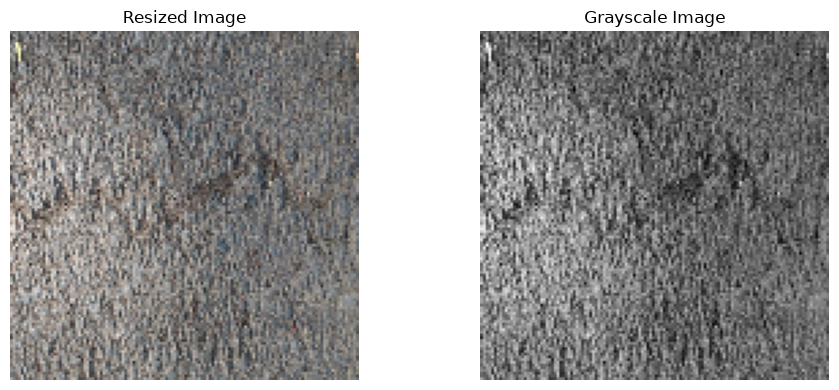

In [26]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

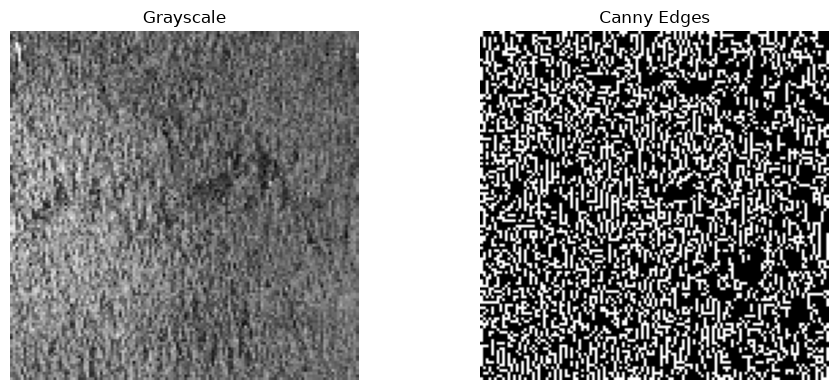

In [27]:
edges = cv2.Canny(
    gray_image,
    100,
    200
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
def extract_features(image_path):
    
    image = cv2.imread(image_path)
    
    if image is None:
        return None
    
    # Resize
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT)
    )
    
    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )
    
    # Normalize intensity to 0-1
    gray_normalized = gray.astype(np.float32) / 255.0
    
    # Basic intensity statistics
    mean_brightness = np.mean(gray_normalized)
    std_brightness = np.std(gray_normalized)
    
    min_intensity = np.min(gray_normalized)
    max_intensity = np.max(gray_normalized)
    
    median_intensity = np.median(gray_normalized)
    
    # Percentiles
    p10 = np.percentile(gray_normalized, 10)
    p25 = np.percentile(gray_normalized, 25)
    p50 = np.percentile(gray_normalized, 50)
    p75 = np.percentile(gray_normalized, 75)
    p90 = np.percentile(gray_normalized, 90)
    
    # Contrast
    contrast = p75 - p25
    
    # Dark pixel ratio
    dark_pixel_ratio = np.mean(
        gray_normalized < 0.30
    )
    
    # Bright pixel ratio
    bright_pixel_ratio = np.mean(
        gray_normalized > 0.70
    )
    
    # Canny edge detection
    edges = cv2.Canny(
        gray,
        100,
        200
    )
    
    # Edge count
    edge_count = np.sum(edges > 0)
    
    # Edge density
    total_pixels = gray.shape[0] * gray.shape[1]
    
    edge_density = edge_count / total_pixels
    
    # Feature dictionary
    features = {
        "mean_brightness": mean_brightness,
        "std_brightness": std_brightness,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "p10_intensity": p10,
        "p25_intensity": p25,
        "p50_intensity": p50,
        "p75_intensity": p75,
        "p90_intensity": p90,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density
    }
    
    return features

In [29]:
test_features = extract_features(crack_images[0])

print("Extracted features:")
print(test_features)

Extracted features:
{'mean_brightness': np.float32(0.47946656), 'std_brightness': np.float32(0.12968923), 'min_intensity': np.float32(0.105882354), 'max_intensity': np.float32(0.96862745), 'median_intensity': np.float32(0.4745098), 'p10_intensity': np.float32(0.3137255), 'p25_intensity': np.float32(0.3882353), 'p50_intensity': np.float32(0.4745098), 'p75_intensity': np.float32(0.5647059), 'p90_intensity': np.float32(0.6509804), 'contrast': np.float32(0.17647061), 'dark_pixel_ratio': np.float64(0.07720947265625), 'bright_pixel_ratio': np.float64(0.055419921875), 'edge_count': np.int64(5580), 'edge_density': np.float64(0.340576171875)}


In [30]:
data = []

for image_path in crack_images:
    
    features = extract_features(image_path)
    
    if features is not None:
        features["image_path"] = image_path
        features["label"] = 1
        data.append(features)

print("Crack images processed:", len(data))

Crack images processed: 200


In [31]:
crack_count = len(data)

for image_path in non_crack_images:
    
    features = extract_features(image_path)
    
    if features is not None:
        features["image_path"] = image_path
        features["label"] = 0
        data.append(features)

print("Total images processed:", len(data))
print("Crack images:", crack_count)
print("Non-crack images:", len(data) - crack_count)

Total images processed: 400
Crack images: 200
Non-crack images: 200


In [35]:
df = pd.DataFrame(data)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (400, 17)


,mean_brightness,std_brightness,min_intensity,max_intensity,median_intensity,p10_intensity,p25_intensity,p50_intensity,p75_intensity,p90_intensity,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,image_path,label
0,0.479467,0.129689,0.105882,0.968627,0.474510,0.313726,0.388235,0.474510,0.564706,0.650980,0.176471,0.077209,0.055420,5580,0.340576,448\Cracks\IMG_20180513_164959951_HDR resized_...,1
1,0.515942,0.099930,0.050980,0.988235,0.521569,0.388235,0.454902,0.521569,0.580392,0.631373,0.125490,0.023132,0.029297,4579,0.279480,448\Cracks\IMG_20180513_165129852_HDR resized_...,1
2,0.474809,0.122080,0.015686,0.929412,0.470588,0.325490,0.403922,0.470588,0.537255,0.635294,0.133333,0.070557,0.047180,4303,0.262634,448\Cracks\IMG_20180513_165150613_HDR resized_...,1
3,0.511016,0.106991,0.031373,0.984314,0.513726,0.372549,0.439216,0.513726,0.584314,0.639216,0.145098,0.027649,0.032715,5507,0.336121,448\Cracks\IMG_20180513_165345878_HDR resized_...,1
4,0.513699,0.108390,0.078431,0.988235,0.517647,0.376471,0.447059,0.517647,0.584314,0.643137,0.137255,0.028870,0.036438,5218,0.318481,448\Cracks\IMG_20180513_165349788_HDR resized_...,1


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_brightness     400 non-null    float32
 1   std_brightness      400 non-null    float32
 2   min_intensity       400 non-null    float32
 3   max_intensity       400 non-null    float32
 4   median_intensity    400 non-null    float32
 5   p10_intensity       400 non-null    float32
 6   p25_intensity       400 non-null    float32
 7   p50_intensity       400 non-null    float32
 8   p75_intensity       400 non-null    float32
 9   p90_intensity       400 non-null    float32
 10  contrast            400 non-null    float32
 11  dark_pixel_ratio    400 non-null    float64
 12  bright_pixel_ratio  400 non-null    float64
 13  edge_count          400 non-null    int64  
 14  edge_density        400 non-null    float64
 15  image_path          400 non-null    str    
 16  label              

In [37]:
print(df.isnull().sum())

mean_brightness       0
std_brightness        0
min_intensity         0
max_intensity         0
median_intensity      0
p10_intensity         0
p25_intensity         0
p50_intensity         0
p75_intensity         0
p90_intensity         0
contrast              0
dark_pixel_ratio      0
bright_pixel_ratio    0
edge_count            0
edge_density          0
image_path            0
label                 0
dtype: int64


In [38]:
print("Class distribution:")

print(
    df["label"].value_counts()
)

print("\n0 = Non-Crack")
print("1 = Crack")

Class distribution:
label
1    200
0    200
Name: count, dtype: int64

0 = Non-Crack
1 = Crack


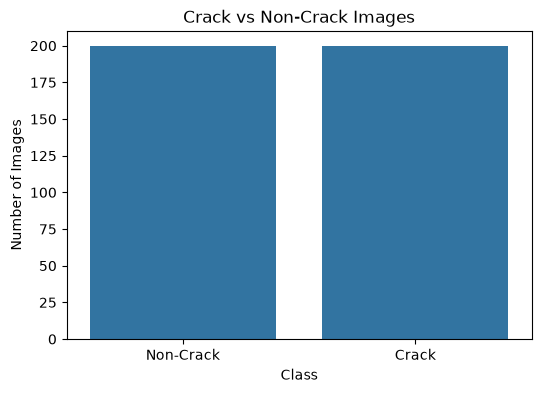

In [39]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="label",
    data=df
)

plt.title("Crack vs Non-Crack Images")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(
    [0, 1],
    ["Non-Crack", "Crack"]
)

plt.show()

In [40]:
feature_columns = [
    "mean_brightness",
    "std_brightness",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "p10_intensity",
    "p25_intensity",
    "p50_intensity",
    "p75_intensity",
    "p90_intensity",
    "contrast",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density"
]

print("Number of features:", len(feature_columns))

Number of features: 15


In [41]:
df[feature_columns].describe()

,mean_brightness,std_brightness,min_intensity,max_intensity,median_intensity,p10_intensity,p25_intensity,p50_intensity,p75_intensity,p90_intensity,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.591467,0.109128,0.191598,0.978882,0.591377,0.453388,0.519601,0.591377,0.663044,0.729945,0.143444,0.023687,0.199527,4449.130000,0.271553
std,0.069641,0.033136,0.127145,0.022094,0.069905,0.098131,0.082119,0.069905,0.066105,0.067140,0.052534,0.036721,0.143572,1716.830455,0.104787
min,0.432884,0.059835,0.000000,0.866667,0.431373,0.176471,0.282353,0.431373,0.482353,0.529412,0.070588,0.000000,0.002441,635.000000,0.038757
25%,0.526564,0.078541,0.093137,0.975490,0.529412,0.371569,0.447059,0.529412,0.623529,0.690196,0.098039,0.000000,0.086411,3055.250000,0.186478
50%,0.598764,0.108211,0.176471,0.984314,0.600000,0.456863,0.523529,0.600000,0.674510,0.745098,0.137255,0.006409,0.185608,5311.500000,0.324188
75%,0.650784,0.132076,0.306863,0.992157,0.647059,0.541176,0.588235,0.647059,0.709804,0.776471,0.172549,0.036499,0.288315,5793.750000,0.353622
max,0.743442,0.221037,0.447059,1.000000,0.745098,0.650980,0.698039,0.745098,0.792157,0.886275,0.384314,0.268677,0.746155,6334.000000,0.386597


In [42]:
df.groupby("label")[feature_columns].mean()

,mean_brightness,std_brightness,min_intensity,max_intensity,median_intensity,p10_intensity,p25_intensity,p50_intensity,p75_intensity,p90_intensity,contrast,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density
label,,,,,,,,,,,,,,,
0,0.617428,0.095682,0.265725,0.975078,0.616382,0.496457,0.552887,0.616382,0.679672,0.738386,0.126784,0.008738,0.201214,3618.635,0.220864
1,0.565506,0.122574,0.117471,0.982686,0.566373,0.410320,0.486314,0.566373,0.646417,0.721504,0.160103,0.038635,0.197841,5279.625,0.322243


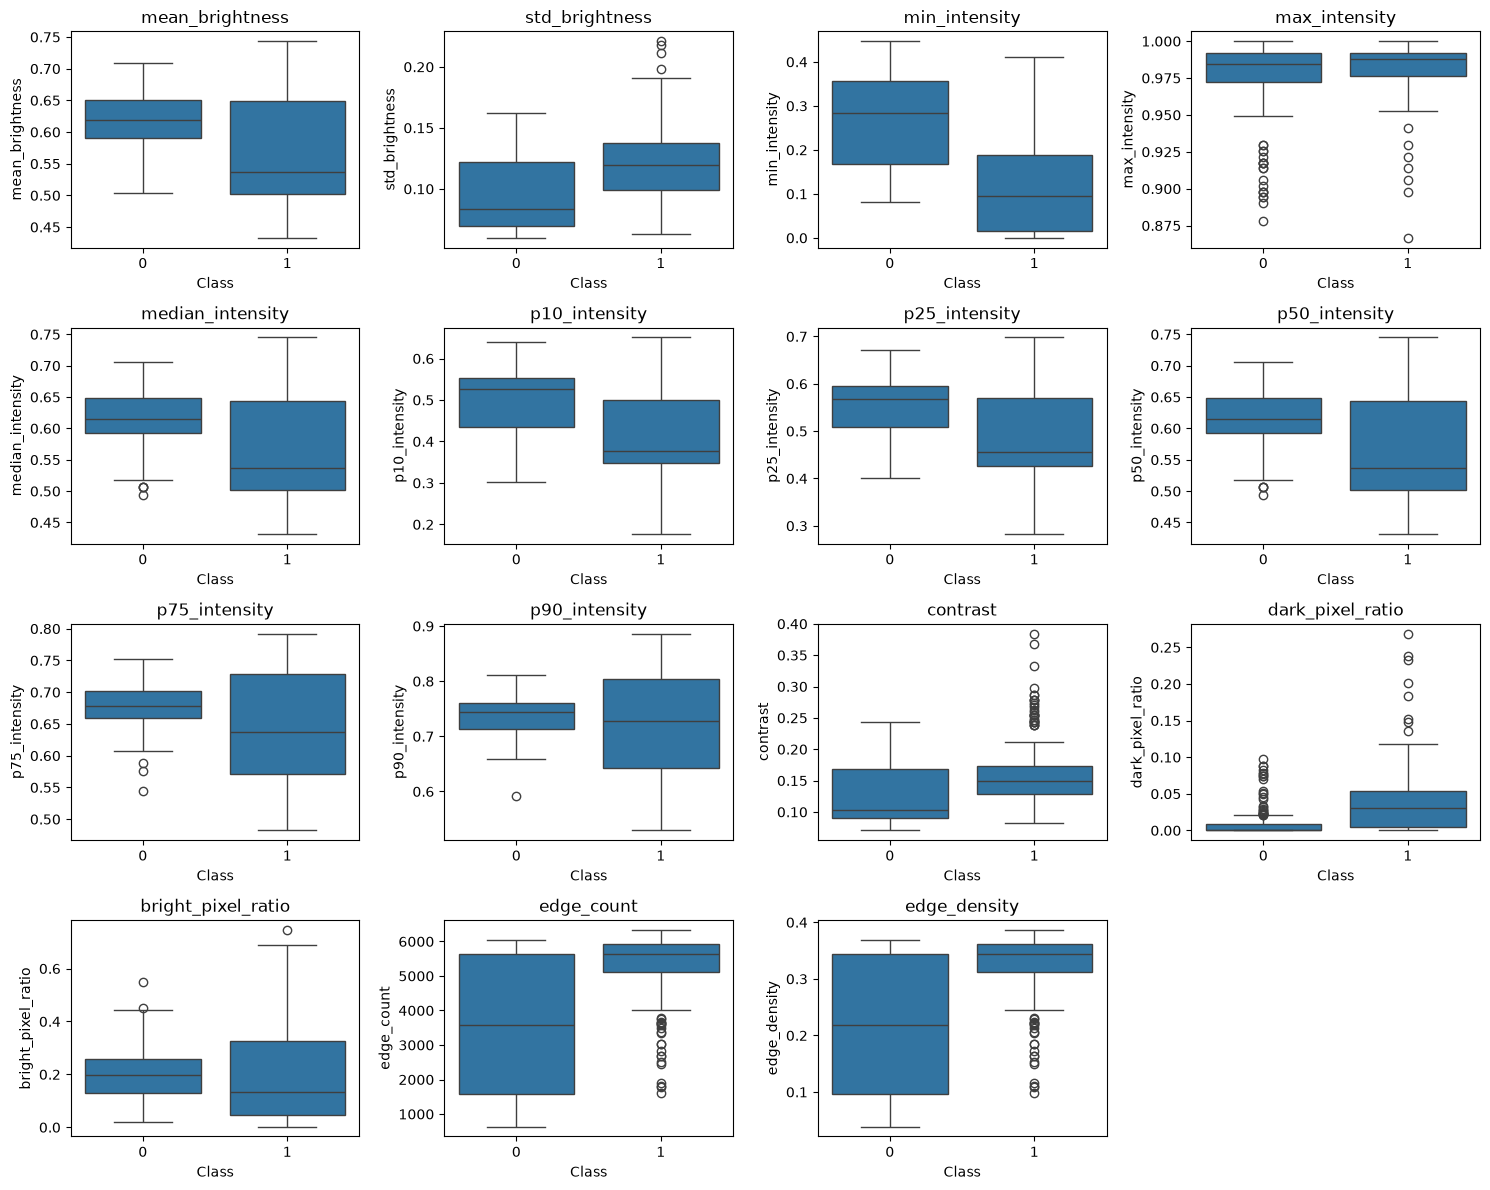

In [43]:
plt.figure(figsize=(15, 12))

for i, feature in enumerate(feature_columns):
    
    plt.subplot(4, 4, i + 1)
    
    sns.boxplot(
        x="label",
        y=feature,
        data=df
    )
    
    plt.title(feature)
    plt.xlabel("Class")

plt.tight_layout()
plt.show()

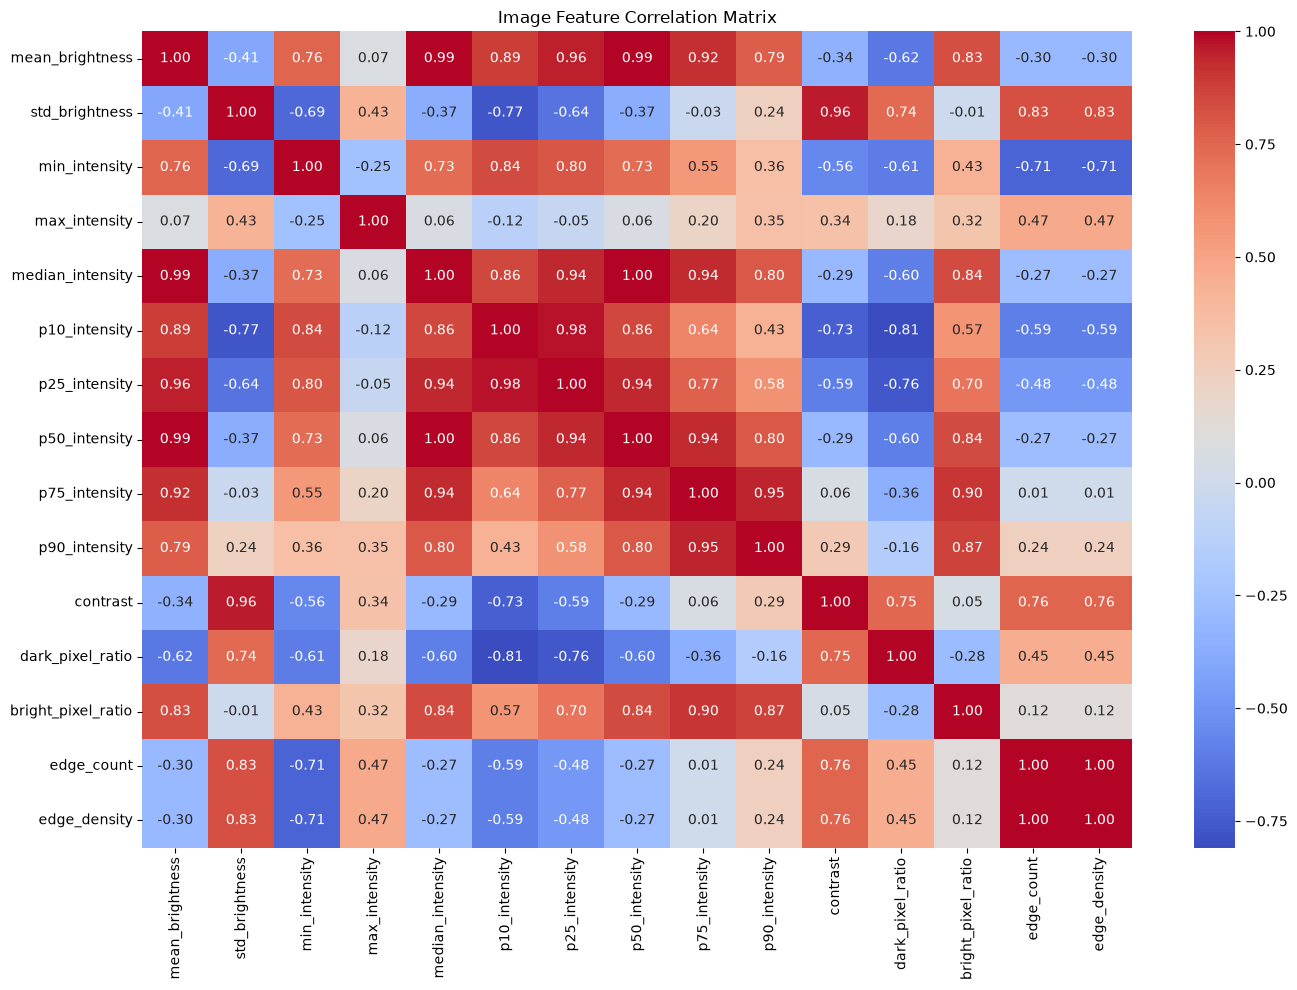

In [44]:
plt.figure(figsize=(14, 10))

correlation = df[feature_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Image Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [45]:
X = df[feature_columns]

y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 15)
y shape: (400,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 320
Testing samples: 80


In [47]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Training time
    start_train = time.perf_counter()
    
    model.fit(
        X_train,
        y_train
    )
    
    end_train = time.perf_counter()
    
    training_time = end_train - start_train
    
    # Prediction time
    start_predict = time.perf_counter()
    
    y_pred = model.predict(X_test)
    
    end_predict = time.perf_counter()
    
    prediction_time = end_predict - start_predict
    
    # Evaluation metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    
    results = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time
    }
    
    return results, y_pred

In [48]:
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_results, logistic_pred = evaluate_model(
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test
)

print(logistic_results)

{'Accuracy': 0.8625, 'Precision': 0.8222222222222222, 'Recall': 0.925, 'F1-Score': 0.8705882352941177, 'Training Time (s)': 0.022203799977432936, 'Prediction Time (s)': 0.002617300022393465}


In [49]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results, rf_pred = evaluate_model(
    random_forest_model,
    X_train,
    X_test,
    y_train,
    y_test
)

print(rf_results)

{'Accuracy': 0.95, 'Precision': 0.95, 'Recall': 0.95, 'F1-Score': 0.95, 'Training Time (s)': 0.14983190002385527, 'Prediction Time (s)': 0.006959199963603169}


In [52]:
svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        SVC(
            kernel="rbf",
            random_state=42
        )
    )
])

svm_results, svm_pred = evaluate_model(
    svm_model,
    X_train,
    X_test,
    y_train,
    y_test
)

print(svm_results)

{'Accuracy': 0.9375, 'Precision': 0.9069767441860465, 'Recall': 0.975, 'F1-Score': 0.9397590361445783, 'Training Time (s)': 0.009394099994096905, 'Prediction Time (s)': 0.0030322999809868634}


In [53]:
results = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Random Forest": rf_results,
    "SVM": svm_results
}).T

results

,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
Logistic Regression,0.8625,0.822222,0.925,0.870588,0.022204,0.002617
Random Forest,0.9500,0.950000,0.950,0.950000,0.149832,0.006959
SVM,0.9375,0.906977,0.975,0.939759,0.009394,0.003032


In [54]:
percentage_results = results[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
] * 100

percentage_results.round(2)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,86.25,82.22,92.5,87.06
Random Forest,95.00,95.00,95.0,95.00
SVM,93.75,90.70,97.5,93.98


In [55]:
time_results = results[
    [
        "Training Time (s)",
        "Prediction Time (s)"
    ]
]

time_results

,Training Time (s),Prediction Time (s)
Logistic Regression,0.022204,0.002617
Random Forest,0.149832,0.006959
SVM,0.009394,0.003032


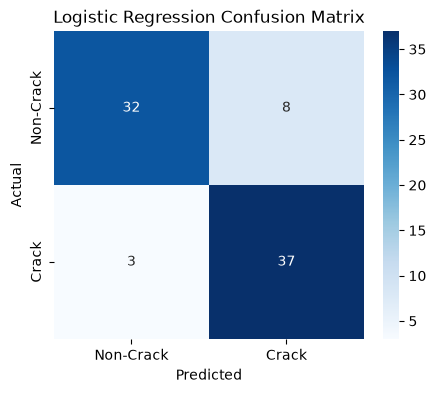

In [56]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Crack", "Crack"],
    yticklabels=["Non-Crack", "Crack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

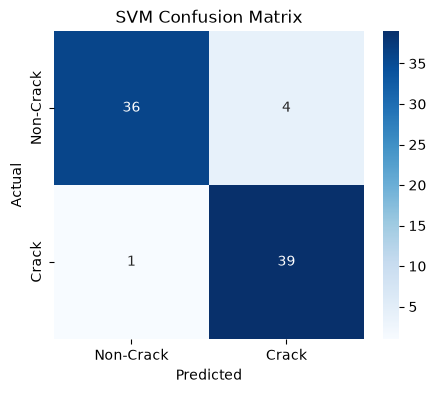

In [59]:
cm_svm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Crack", "Crack"],
    yticklabels=["Non-Crack", "Crack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [60]:
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["Non-Crack", "Crack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Crack       0.91      0.80      0.85        40
       Crack       0.82      0.93      0.87        40

    accuracy                           0.86        80
   macro avg       0.87      0.86      0.86        80
weighted avg       0.87      0.86      0.86        80



In [61]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Non-Crack", "Crack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Crack       0.95      0.95      0.95        40
       Crack       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



In [62]:
print(
    classification_report(
        y_test,
        svm_pred,
        target_names=["Non-Crack", "Crack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Crack       0.97      0.90      0.94        40
       Crack       0.91      0.97      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



In [63]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,p90_intensity,0.139236
2,min_intensity,0.104240
12,bright_pixel_ratio,0.080097
7,p50_intensity,0.077761
14,edge_density,0.075621
0,mean_brightness,0.073866
13,edge_count,0.072579
11,dark_pixel_ratio,0.069463
8,p75_intensity,0.068905
4,median_intensity,0.068465


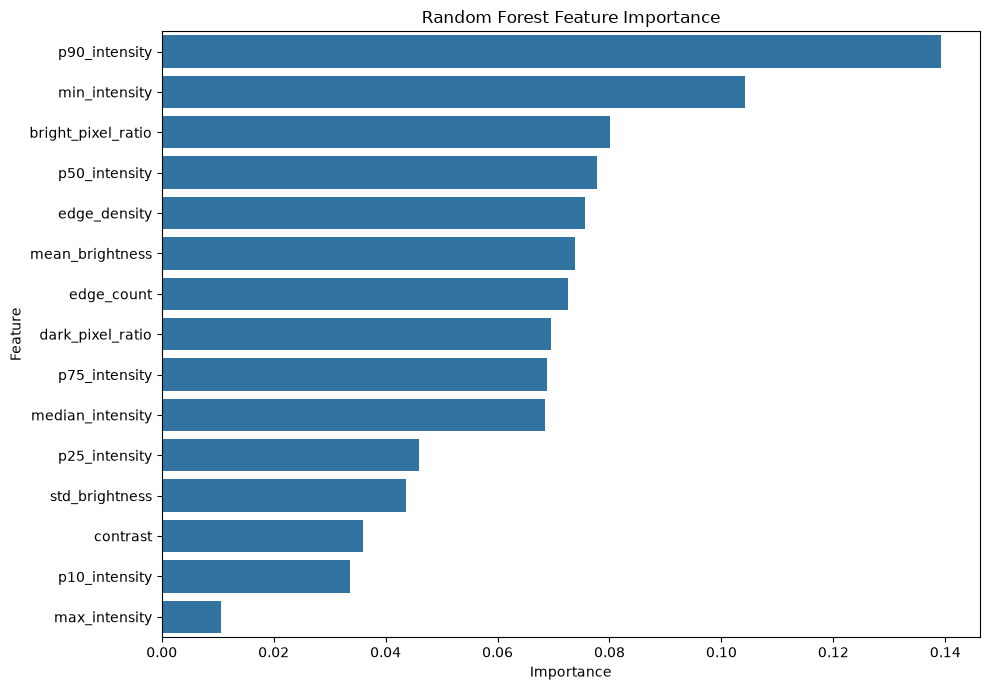

In [64]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Part C — Improve Image Representation

In [65]:
def extract_improved_features(image_path):
    
    image = cv2.imread(image_path)
    
    if image is None:
        return None
    
    # Resize
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT)
    )
    
    # Grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )
    
    # Normalize
    gray_normalized = gray.astype(
        np.float32
    ) / 255.0
    
    # Intensity features
    mean_brightness = np.mean(
        gray_normalized
    )
    
    std_brightness = np.std(
        gray_normalized
    )
    
    dark_pixel_ratio = np.mean(
        gray_normalized < 0.30
    )
    
    bright_pixel_ratio = np.mean(
        gray_normalized > 0.70
    )
    
    p25 = np.percentile(
        gray_normalized,
        25
    )
    
    p75 = np.percentile(
        gray_normalized,
        75
    )
    
    contrast = p75 - p25
    
    # Original Canny thresholds
    edges_original = cv2.Canny(
        gray,
        100,
        200
    )
    
    # Improved lower Canny thresholds
    edges_improved = cv2.Canny(
        gray,
        50,
        150
    )
    
    total_pixels = (
        gray.shape[0] *
        gray.shape[1]
    )
    
    original_edge_density = (
        np.sum(edges_original > 0)
        / total_pixels
    )
    
    improved_edge_density = (
        np.sum(edges_improved > 0)
        / total_pixels
    )
    
    features = {
        "mean_brightness": mean_brightness,
        "std_brightness": std_brightness,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "contrast": contrast,
        "original_edge_density": original_edge_density,
        "improved_edge_density": improved_edge_density
    }
    
    return features

In [66]:
improved_data = []

for image_path in crack_images:
    
    features = extract_improved_features(
        image_path
    )
    
    if features is not None:
        features["label"] = 1
        improved_data.append(features)


for image_path in non_crack_images:
    
    features = extract_improved_features(
        image_path
    )
    
    if features is not None:
        features["label"] = 0
        improved_data.append(features)


improved_df = pd.DataFrame(
    improved_data
)

print(
    "Improved dataset shape:",
    improved_df.shape
)

improved_df.head()

Improved dataset shape: (400, 8)


,mean_brightness,std_brightness,dark_pixel_ratio,bright_pixel_ratio,contrast,original_edge_density,improved_edge_density,label
0,0.479467,0.129689,0.077209,0.055420,0.176471,0.340576,0.366760,1
1,0.515942,0.099930,0.023132,0.029297,0.125490,0.279480,0.361023,1
2,0.474809,0.122080,0.070557,0.047180,0.133333,0.262634,0.347595,1
3,0.511016,0.106991,0.027649,0.032715,0.145098,0.336121,0.370972,1
4,0.513699,0.108390,0.028870,0.036438,0.137255,0.318481,0.361267,1


In [67]:
improved_feature_columns = [
    "mean_brightness",
    "std_brightness",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "contrast",
    "original_edge_density",
    "improved_edge_density"
]

X_improved = improved_df[
    improved_feature_columns
]

y_improved = improved_df[
    "label"
]

print(
    "Original feature count:",
    len(feature_columns)
)

print(
    "Improved feature count:",
    len(improved_feature_columns)
)

Original feature count: 15
Improved feature count: 7


In [68]:
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved
)

print(
    "Improved training samples:",
    len(X_train_imp)
)

print(
    "Improved testing samples:",
    len(X_test_imp)
)

Improved training samples: 320
Improved testing samples: 80


In [69]:
improved_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

improved_rf_results, improved_rf_pred = evaluate_model(
    improved_rf_model,
    X_train_imp,
    X_test_imp,
    y_train_imp,
    y_test_imp
)

print(improved_rf_results)

{'Accuracy': 0.9375, 'Precision': 0.926829268292683, 'Recall': 0.95, 'F1-Score': 0.9382716049382716, 'Training Time (s)': 0.1573659999994561, 'Prediction Time (s)': 0.007748399977572262}


In [70]:
improved_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

improved_rf_results, improved_rf_pred = evaluate_model(
    improved_rf_model,
    X_train_imp,
    X_test_imp,
    y_train_imp,
    y_test_imp
)

print(improved_rf_results)

{'Accuracy': 0.9375, 'Precision': 0.926829268292683, 'Recall': 0.95, 'F1-Score': 0.9382716049382716, 'Training Time (s)': 0.15771810000296682, 'Prediction Time (s)': 0.00756060000276193}


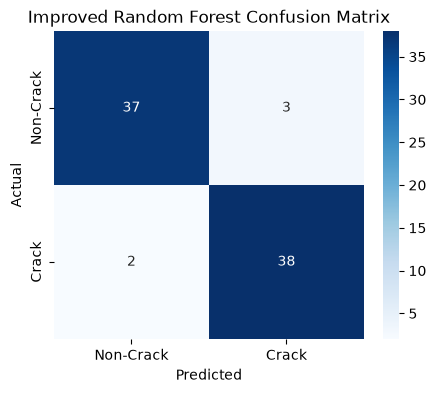

In [71]:
cm_improved = confusion_matrix(
    y_test_imp,
    improved_rf_pred
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_improved,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Crack", "Crack"],
    yticklabels=["Non-Crack", "Crack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Improved Random Forest Confusion Matrix")

plt.show()

In [72]:
rf_comparison = pd.DataFrame({
    "Original Random Forest": rf_results,
    "Improved Random Forest": improved_rf_results
}).T

rf_comparison

,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
Original Random Forest,0.9500,0.950000,0.95,0.950000,0.149832,0.006959
Improved Random Forest,0.9375,0.926829,0.95,0.938272,0.157718,0.007561


In [73]:
rf_percentage_comparison = rf_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
] * 100

rf_percentage_comparison.round(2)

,Accuracy,Precision,Recall,F1-Score
Original Random Forest,95.00,95.00,95.0,95.00
Improved Random Forest,93.75,92.68,95.0,93.83


In [74]:
rf_time_comparison = rf_comparison[
    [
        "Training Time (s)",
        "Prediction Time (s)"
    ]
]

rf_time_comparison

,Training Time (s),Prediction Time (s)
Original Random Forest,0.149832,0.006959
Improved Random Forest,0.157718,0.007561


In [75]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Improved Random Forest"
    ],
    
    "Accuracy": [
        logistic_results["Accuracy"],
        rf_results["Accuracy"],
        svm_results["Accuracy"],
        improved_rf_results["Accuracy"]
    ],
    
    "Precision": [
        logistic_results["Precision"],
        rf_results["Precision"],
        svm_results["Precision"],
        improved_rf_results["Precision"]
    ],
    
    "Recall": [
        logistic_results["Recall"],
        rf_results["Recall"],
        svm_results["Recall"],
        improved_rf_results["Recall"]
    ],
    
    "F1-Score": [
        logistic_results["F1-Score"],
        rf_results["F1-Score"],
        svm_results["F1-Score"],
        improved_rf_results["F1-Score"]
    ],
    
    "Training Time (s)": [
        logistic_results["Training Time (s)"],
        rf_results["Training Time (s)"],
        svm_results["Training Time (s)"],
        improved_rf_results["Training Time (s)"]
    ],
    
    "Prediction Time (s)": [
        logistic_results["Prediction Time (s)"],
        rf_results["Prediction Time (s)"],
        svm_results["Prediction Time (s)"],
        improved_rf_results["Prediction Time (s)"]
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.8625,0.822222,0.925,0.870588,0.022204,0.002617
1,Random Forest,0.9500,0.950000,0.950,0.950000,0.149832,0.006959
2,SVM,0.9375,0.906977,0.975,0.939759,0.009394,0.003032
3,Improved Random Forest,0.9375,0.926829,0.950,0.938272,0.157718,0.007561


In [76]:
final_results_percentage = final_results.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]:
    
    final_results_percentage[column] = (
        final_results_percentage[column] * 100
    ).round(2)

final_results_percentage

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,86.25,82.22,92.5,87.06,0.022204,0.002617
1,Random Forest,95.00,95.00,95.0,95.00,0.149832,0.006959
2,SVM,93.75,90.70,97.5,93.98,0.009394,0.003032
3,Improved Random Forest,93.75,92.68,95.0,93.83,0.157718,0.007561


In [77]:
df.to_csv(
    "asphalt_crack_image_features.csv",
    index=False
)

print(
    "Original image features saved."
)

Original image features saved.


In [78]:
improved_df.to_csv(
    "asphalt_crack_improved_features.csv",
    index=False
)

print(
    "Improved image features saved."
)

Improved image features saved.


In [79]:
final_results_percentage.to_csv(
    "asphalt_crack_model_results.csv",
    index=False
)

print(
    "Model results saved."
)

Model results saved.


In [80]:
print("=" * 60)
print("PART A - IMAGE CLASSIFICATION SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Total images:", len(df))
print("Crack images:", (df["label"] == 1).sum())
print("Non-crack images:", (df["label"] == 0).sum())

print("\nImage size:")
print(f"{IMG_WIDTH} x {IMG_HEIGHT}")

print("\nOriginal features:", len(feature_columns))
print("Improved features:", len(improved_feature_columns))

print("\nModel Results:")
print(final_results_percentage.to_string(index=False))

print("\nNo deep learning was used.")
print("All image features were extracted using NumPy/OpenCV.")
print("All classifiers are traditional machine-learning models.")

PART A - IMAGE CLASSIFICATION SUMMARY

Dataset:
Total images: 400
Crack images: 200
Non-crack images: 200

Image size:
128 x 128

Original features: 15
Improved features: 7

Model Results:
                 Model  Accuracy  Precision  Recall  F1-Score  Training Time (s)  Prediction Time (s)
   Logistic Regression     86.25      82.22    92.5     87.06           0.022204             0.002617
         Random Forest     95.00      95.00    95.0     95.00           0.149832             0.006959
                   SVM     93.75      90.70    97.5     93.98           0.009394             0.003032
Improved Random Forest     93.75      92.68    95.0     93.83           0.157718             0.007561

No deep learning was used.
All image features were extracted using NumPy/OpenCV.
All classifiers are traditional machine-learning models.
